In [397]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.tsa.seasonal as seasonal
import seaborn as sns

**Introduction**

Accurate solar generation forecasts are essential for battery optimisation systems. If solar output is underestimated, the battery over-charges from the grid overnight, paying for electricity that could have come from solar. If overestimated, the battery under-charges and the customer draws expensive grid power during peak hours.

This notebook develops a 48-hour-ahead forecasting tool for solar PV generation at a single site using two different ML approaches: XGBoost and Ridge regression.

**Dataset**

The dataset is sourced from Kaggle and contains generation and weather sensor data from a solar power plant in India, covering 34 days (15 May - 17 June 2020) at 15-minute resolution. The plant has 22 inverters, each reporting DC power, AC power, daily yield, and total yield. A single weather sensor records ambient temperature, module temperature, and irradiation.

The data was aggregated from inverter level to site level by taking the mean across all 22 inverters per timestamp, then resampled from 15-minute to 30-minute intervals to match the required half-hourly forecast granularity. This gives approximately 1,600 half-hourly observations.

Key constraints: only 34 days of data limits the model's ability to learn seasonal patterns. No weather forecast data is available for the prediction horizon - the model must rely on historical patterns and solar position features to predict 48 hours ahead.

### Load Data

In [398]:
energy = pd.read_csv('../data/Plant_1_Generation_Data.csv')
weather = pd.read_csv('../data/Plant_1_Weather_Sensor_Data.csv')

energy['DATE_TIME'] = pd.to_datetime(energy['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

In [399]:
weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [400]:
energy['DATE_TIME'].is_monotonic_increasing

True

In [401]:
weather['DATE_TIME'].is_monotonic_increasing

True

In [402]:
energy.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [403]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[ns]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  object        
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 3.7+ MB


In [404]:
energy.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,2020-06-01 08:02:49.458256896,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,2020-06-01 14:30:00,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,2020-06-09 20:00:00,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06
std,NaN,0.0,4036.457169,394.396439,3145.178309,4.162720e+05


### Aggregate Across All Sources Keys

Source keys are IDs for the 22 individual inverters at the solar plant. Each inverter takes DC power from a group of panels and converts it to AC power. I aggregated 22 inverters to mean per timestamp.

In [405]:
energy['SOURCE_KEY'].nunique()

22

In [406]:
# Correlation between inverters at each timestamp
pivot = energy.pivot_table(values='AC_POWER', index='DATE_TIME', columns='SOURCE_KEY')
print(pivot.corr().mean().mean())

0.9878970808736743


In [407]:
plant = energy.groupby('DATE_TIME').agg({
    'DC_POWER': 'mean',
    'AC_POWER': 'mean',
    'DAILY_YIELD': 'mean',
    'TOTAL_YIELD': 'mean',
}).reset_index()

print(f'Shape: {plant.shape}')
print(f'Date range: {plant["DATE_TIME"].min()} → {plant["DATE_TIME"].max()}')
print(f'Rows: {len(plant)}')

Shape: (3158, 5)
Date range: 2020-05-15 00:00:00 → 2020-06-17 23:45:00
Rows: 3158


In [408]:
plant.head()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,0.0,0.0,0.0,6.837223e+06
1,2020-05-15 00:15:00,0.0,0.0,0.0,6.837223e+06
2,2020-05-15 00:30:00,0.0,0.0,0.0,6.837223e+06
3,2020-05-15 00:45:00,0.0,0.0,0.0,6.837223e+06
4,2020-05-15 01:00:00,0.0,0.0,0.0,6.852802e+06


### Plot Target Variable

AC_POWER is the mean alternating current power output across 22 inverters at the solar plant, measured in kilowatts (kW). This is the usable electricity that gets exported to the grid or stored in batteries. This will also be the forecasted variable. The time series shows the characteristic daily solar cycle.

<Axes: xlabel='DATE_TIME'>

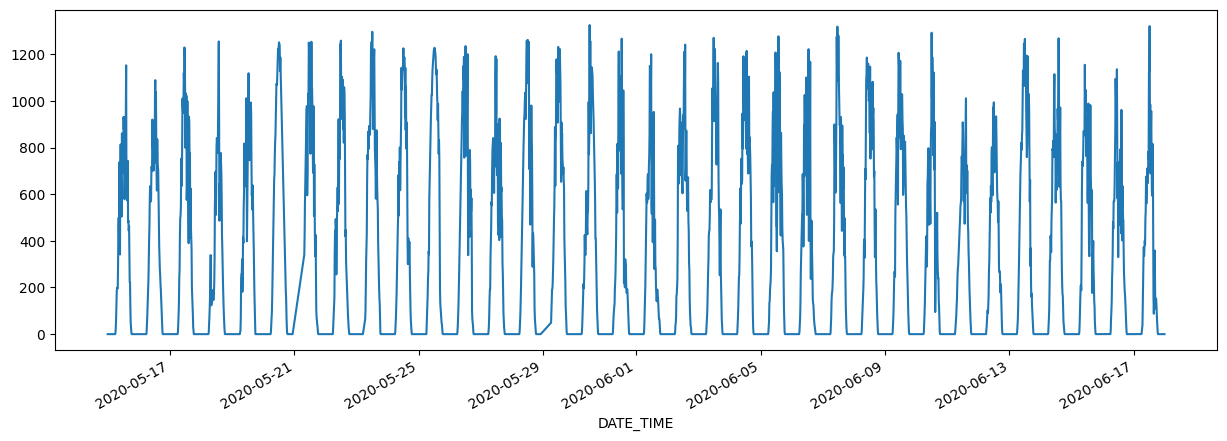

In [409]:
plant.set_index('DATE_TIME')['AC_POWER'].plot(figsize=(15, 5))

### Weather

In [410]:
weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


AMBIENT_TEMPERATURE — air temperature at the site (°C). Hotter ambient temperatures can potentially reduce solar panel efficiency.  

MODULE_TEMPERATURE — temperature of the solar panels themselves. Panels heat up in direct sunlight. Higher module temperature can lower efficiency. 

IRRADIATION — how much sunlight is hitting the panels (W/m²). More irradiation = more solar power.

### Merge Both Datasets

In [411]:
full_index = pd.date_range(start=plant['DATE_TIME'].min(), end=plant['DATE_TIME'].max(), freq='15min')

plant = plant.set_index('DATE_TIME').reindex(full_index).reset_index().rename(columns={'index': 'DATE_TIME'})
weather = weather.set_index('DATE_TIME').reindex(full_index).reset_index().rename(columns={'index': 'DATE_TIME'})

In [412]:
df = plant.merge(weather, on='DATE_TIME', how='outer')
df = df.sort_values('DATE_TIME').reset_index(drop=True)

In [413]:
print(df.isnull().sum())

DATE_TIME                0
DC_POWER               106
AC_POWER               106
DAILY_YIELD            106
TOTAL_YIELD            106
PLANT_ID                82
SOURCE_KEY              82
AMBIENT_TEMPERATURE     82
MODULE_TEMPERATURE      82
IRRADIATION             82
dtype: int64


In [414]:
df = df.drop(columns=['PLANT_ID','SOURCE_KEY']) # Won't be used in modelling

### Missing Values

Both datasets include some missing timestamps. Missing gaps for AC Power are shown below, which suggest that linear interpolation is sufficient (DC Power follows AC trend, temperature and cumulative yield grows linearly).

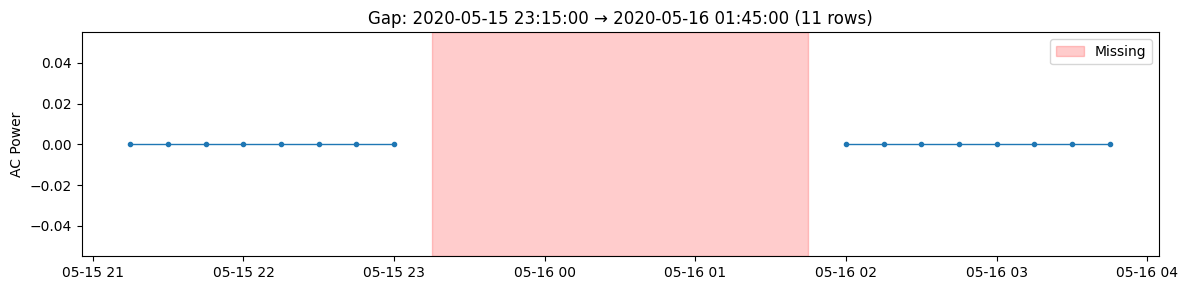

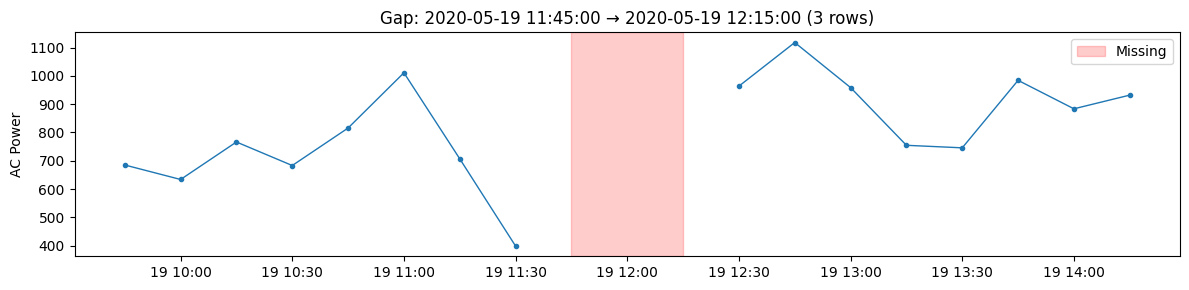

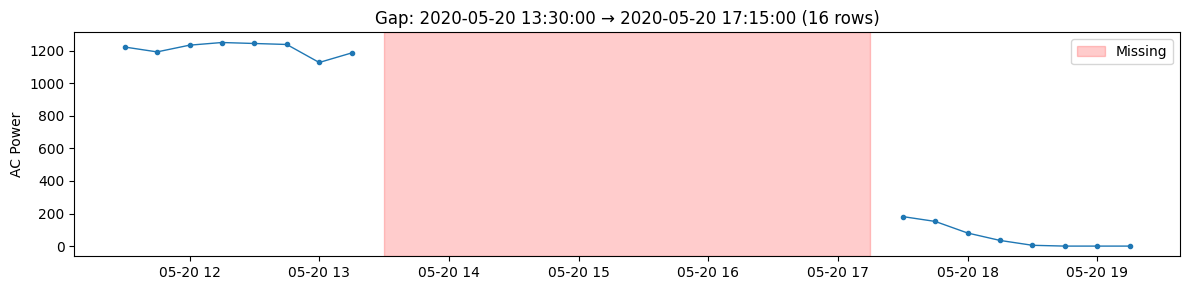

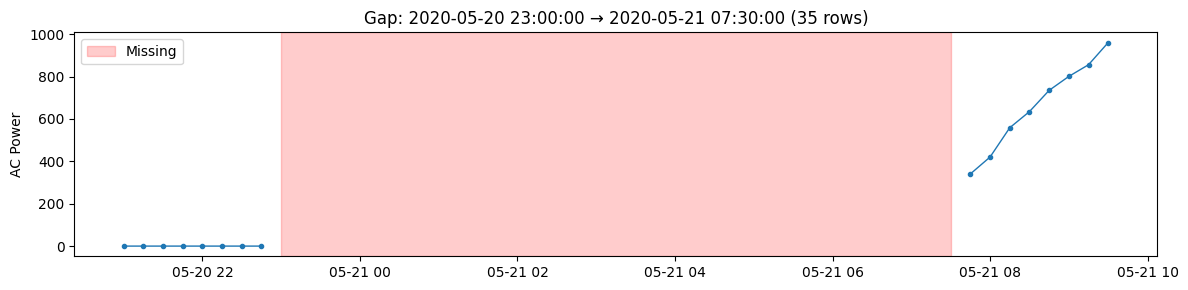

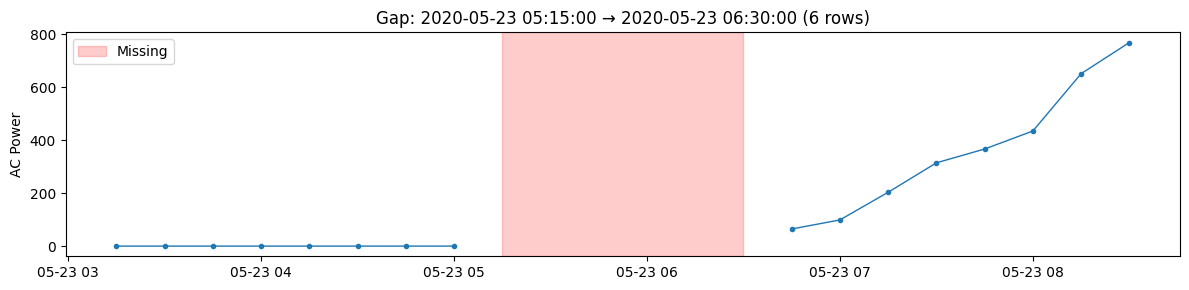

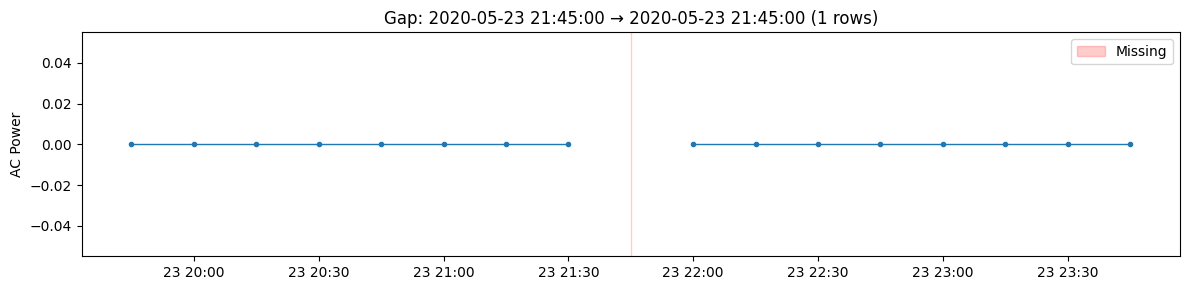

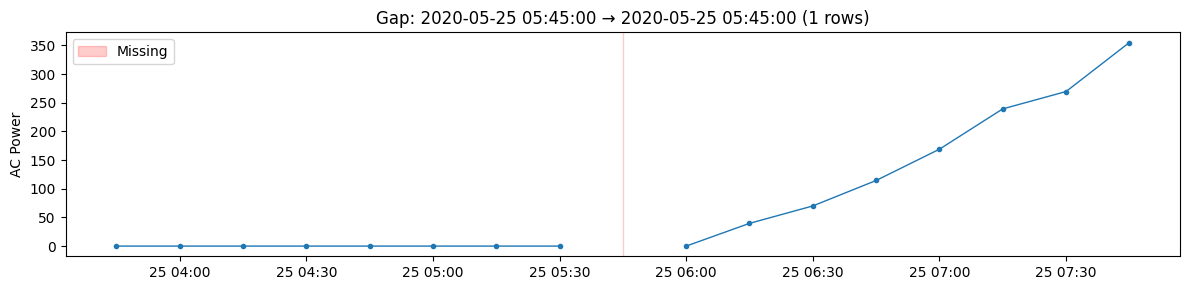

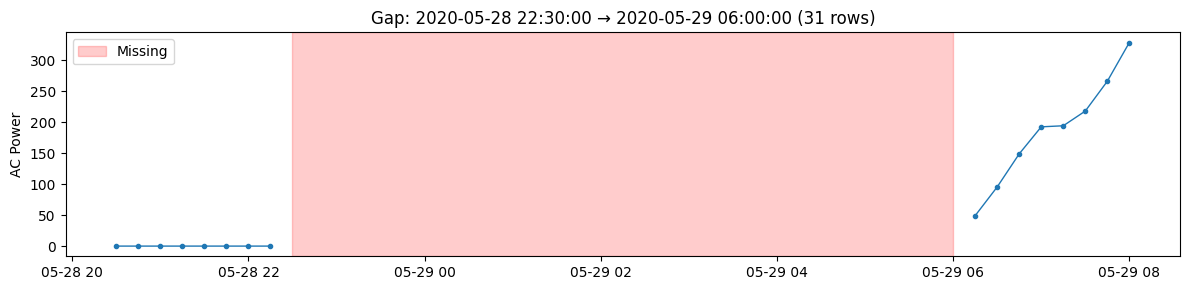

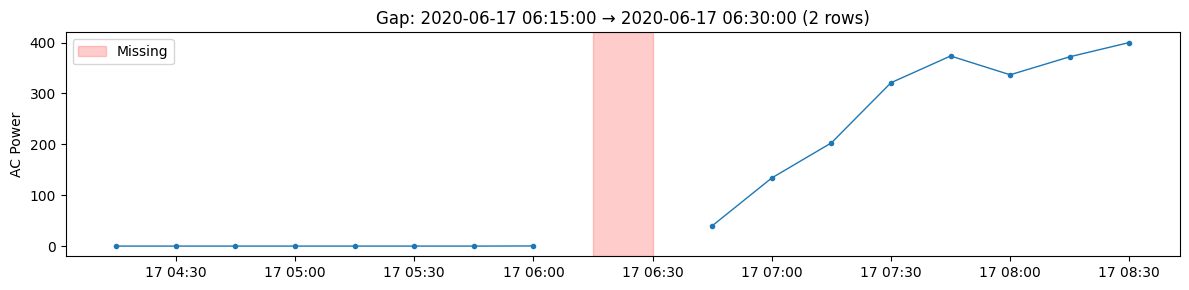

In [415]:
missing_blocks = df[df['AC_POWER'].isnull()].groupby(
    df['AC_POWER'].isnull().ne(df['AC_POWER'].isnull().shift()).cumsum()
)['DATE_TIME'].agg(['first', 'last', 'count'])

for _, block in missing_blocks.iterrows():
    start = block['first'] - pd.Timedelta(hours=2)
    end = block['last'] + pd.Timedelta(hours=2)
    window = df[(df['DATE_TIME'] >= start) & (df['DATE_TIME'] <= end)]
    
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(window['DATE_TIME'], window['AC_POWER'], marker='.', linewidth=1)
    ax.axvspan(block['first'], block['last'], color='red', alpha=0.2, label='Missing')
    ax.set_title(f'Gap: {block["first"]} → {block["last"]} ({block["count"]} rows)')
    ax.set_ylabel('AC Power')
    ax.legend()
    plt.tight_layout()
    plt.show()

#### Before filling 2 main daytime gaps

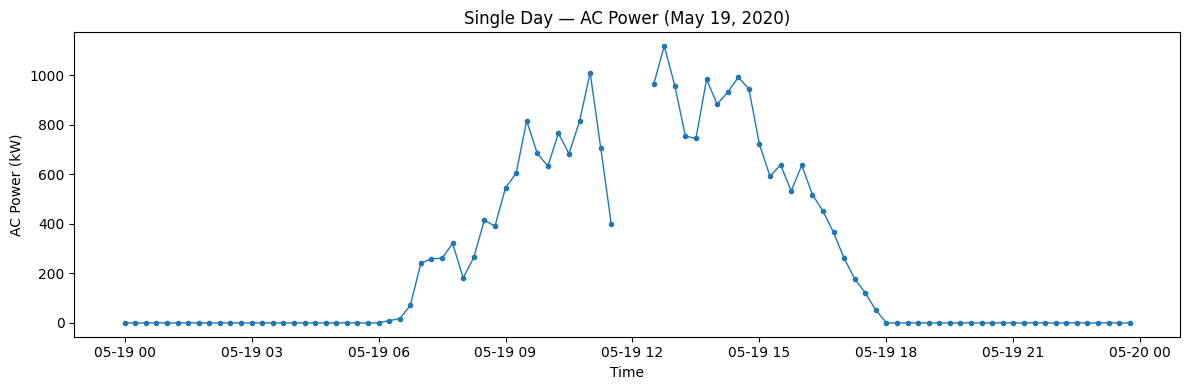

In [416]:
day = df[(df['DATE_TIME'] >= '2020-05-19') & (df['DATE_TIME'] < '2020-05-20')]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(day['DATE_TIME'], day['AC_POWER'], marker='.', linewidth=1)
ax.set_title('Single Day — AC Power (May 19, 2020)')
ax.set_ylabel('AC Power (kW)')
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()

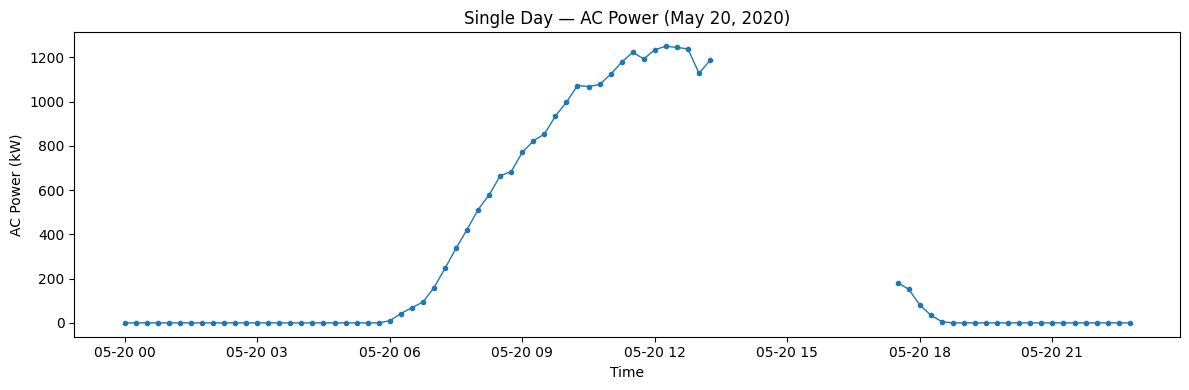

In [417]:
day = df[(df['DATE_TIME'] >= '2020-05-20') & (df['DATE_TIME'] < '2020-05-21')]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(day['DATE_TIME'], day['AC_POWER'], marker='.', linewidth=1)
ax.set_title('Single Day — AC Power (May 20, 2020)')
ax.set_ylabel('AC Power (kW)')
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()

#### Filling missing values

In [418]:
night_null = df['AC_POWER'].isnull() & ~df['DATE_TIME'].dt.hour.between(5, 19)
df.loc[night_null, 'AC_POWER'] = 0
df['AC_POWER'] = df['AC_POWER'].interpolate(method='linear')
df['AC_POWER'] = df['AC_POWER'].clip(lower=0)

night_null = df['DC_POWER'].isnull() & ~df['DATE_TIME'].dt.hour.between(5, 19)
df.loc[night_null, 'DC_POWER'] = 0
df['DC_POWER'] = df['DC_POWER'].interpolate(method='linear')
df['DC_POWER'] = df['DC_POWER'].clip(lower=0)

night_irr_null = df['IRRADIATION'].isnull() & ~df['DATE_TIME'].dt.hour.between(5, 19)
df.loc[night_irr_null, 'IRRADIATION'] = 0
df['IRRADIATION'] = df['IRRADIATION'].interpolate(method='linear')
df['IRRADIATION'] = df['IRRADIATION'].clip(lower=0)

df['AMBIENT_TEMPERATURE'] = df['AMBIENT_TEMPERATURE'].interpolate(method='linear')
df['MODULE_TEMPERATURE'] = df['MODULE_TEMPERATURE'].interpolate(method='linear')

df['DAILY_YIELD'] = df['DAILY_YIELD'].interpolate(method='linear')
df['TOTAL_YIELD'] = df['TOTAL_YIELD'].interpolate(method='linear')

#### After filling 2 main daytime gaps

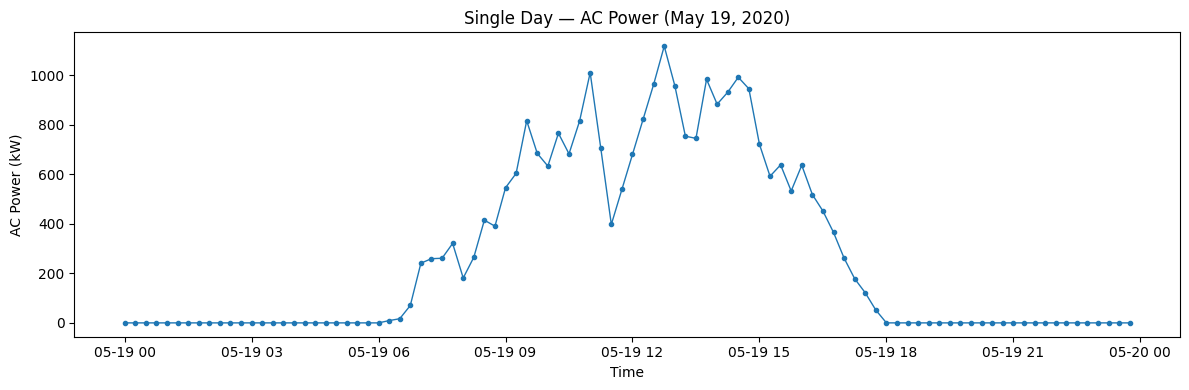

In [419]:
day = df[(df['DATE_TIME'] >= '2020-05-19') & (df['DATE_TIME'] < '2020-05-20')]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(day['DATE_TIME'], day['AC_POWER'], marker='.', linewidth=1)
ax.set_title('Single Day — AC Power (May 19, 2020)')
ax.set_ylabel('AC Power (kW)')
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()

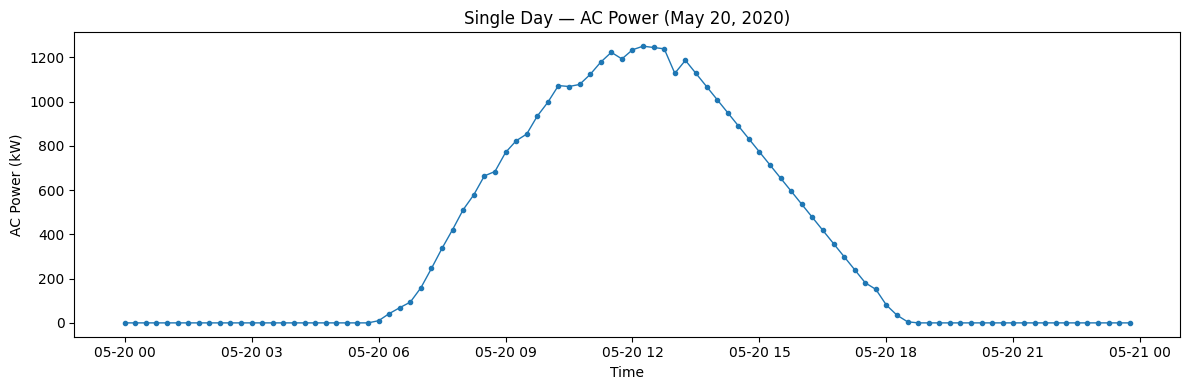

In [420]:
day = df[(df['DATE_TIME'] >= '2020-05-20') & (df['DATE_TIME'] < '2020-05-21')]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(day['DATE_TIME'], day['AC_POWER'], marker='.', linewidth=1)
ax.set_title('Single Day — AC Power (May 20, 2020)')
ax.set_ylabel('AC Power (kW)')
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()

In [421]:
print(df.isnull().sum())

DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


### Seasonal Decomposition - Target

Shows a consistent daily solar cycle repeating every 24 hours. Zero output overnight. The weekly cycle plot shows some trend of gradual overall decline from May into June which could be consistent with the approaching Indian monsoon season bringing increased cloud cover.

#### Daily cycle

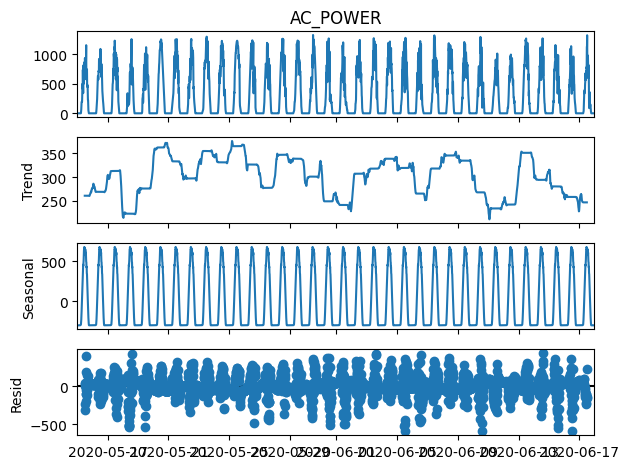

In [422]:
df.set_index('DATE_TIME', inplace=True)

# Decompose AC_POWER to detect trend and seasonality
# Period=96 for 15min data to get daily seasonality
decomposition_ac = seasonal.seasonal_decompose(df['AC_POWER'], model='additive', period=96)
decomposition_ac.plot();


#### Weekly cycle

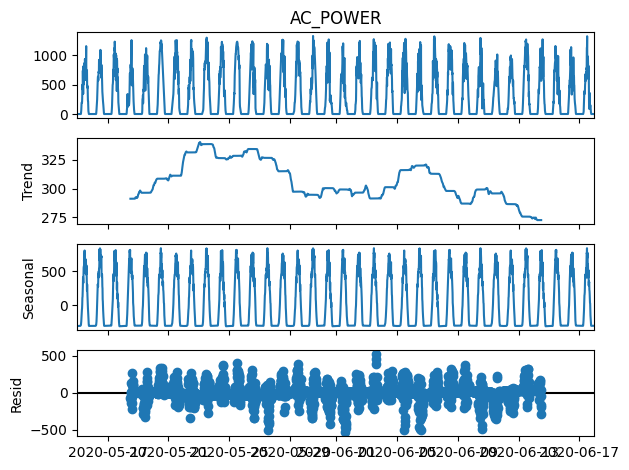

In [423]:
# Period=672 for weekly seasonality
decomposition_ac = seasonal.seasonal_decompose(df['AC_POWER'], model='additive', period=672)
decomposition_ac.plot()

df.reset_index(inplace=True)

### Correlations Between Columns

Irradiation drives AC power almost perfectly (r=0.997). DC and module temperature are also highly correlated with the target but both are just proxies for sunlight. Ambient temperature (r=0.74) is the most independent weather signal. DAILY_YIELD and TOTAL_YIELD show low correlation with instantaneous power as they are cumulative measures.

<Axes: >

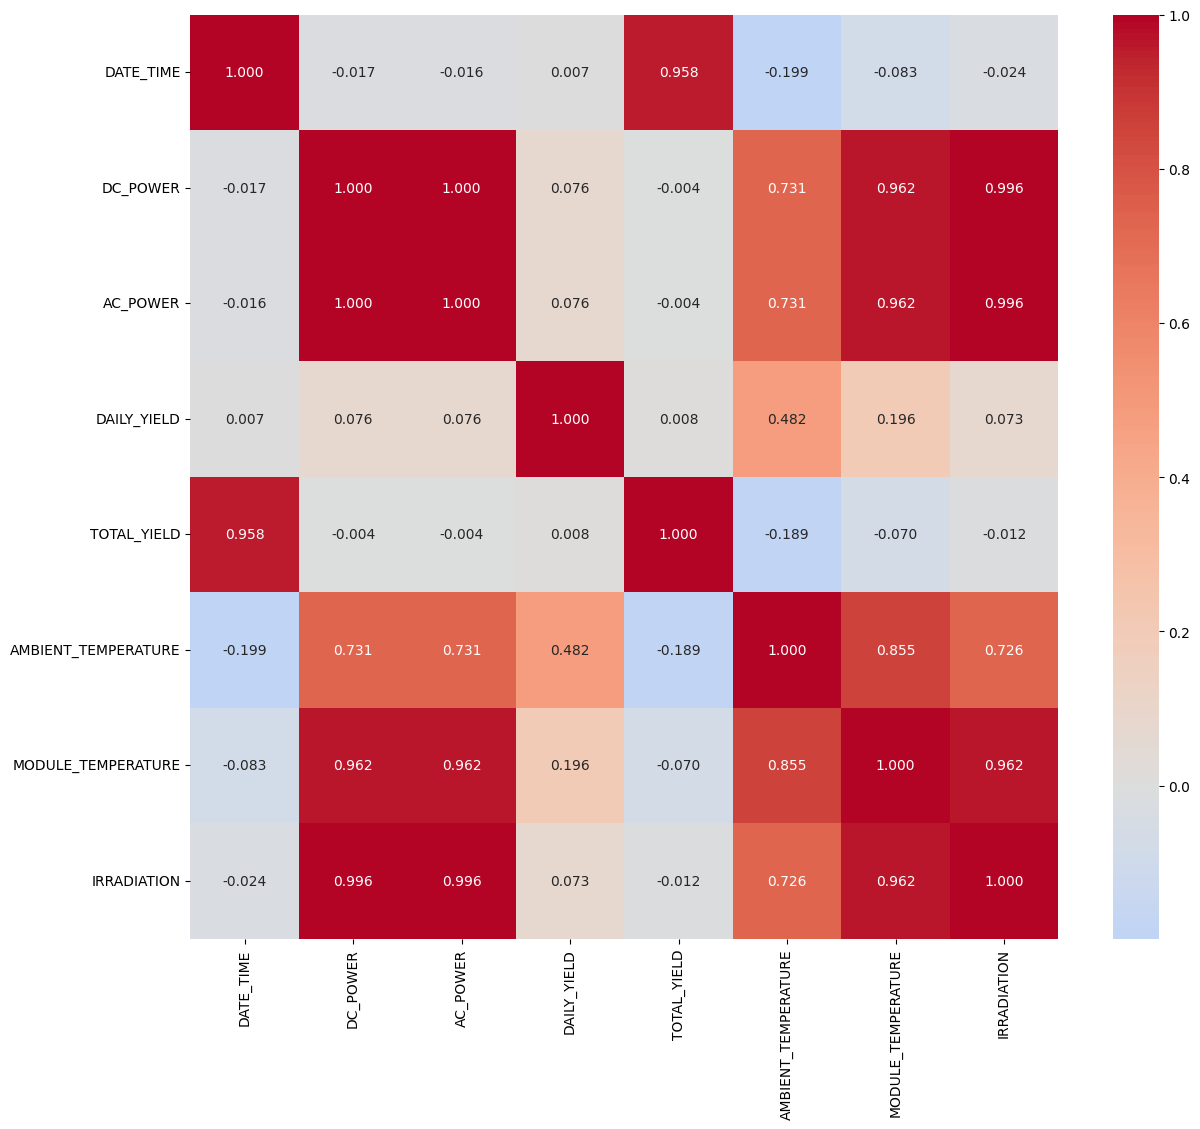

In [424]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(df.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)

### Resample To 30min Timestamps And Save

Resampled from 15-minute to 30-minute intervals to match the task requirement of half-hourly forecasts. This reduces the dataset from ~3,200 to ~1,600 rows. Values are averaged across each 30-minute window.

In [425]:
df = df.set_index('DATE_TIME').resample('30min').mean().reset_index()
df.shape

(1632, 8)

In [426]:
df.to_csv('../data/plant_weather_merged.csv', index=False)